In [1]:
!ls ../input/1-mpn


ls: cannot access '../input/1-mpn': No such file or directory


In [2]:
!ls ../input/
!ls ../input/nnet-b-seed-10
!ls ../input/nnet-b-seed-11
!ls ../input/nnet-b-seed-12

champs-scalar-coupling		    sample_submission.csv.zip
description.md			    scalar_coupling_contributions.csv
dipole_moments.csv		    scalar_coupling_contributions.csv.zip
dipole_moments.csv.zip		    structures
magnetic_shielding_tensors.csv	    structures.csv
magnetic_shielding_tensors.csv.zip  structures.csv.zip
mulliken_charges.csv		    structures.zip
mulliken_charges.csv.zip	    test.csv
potential_energy.csv		    test.csv.zip
potential_energy.csv.zip	    train.csv
sample_submission.csv		    train.csv.zip
ls: cannot access '../input/nnet-b-seed-10': No such file or directory
ls: cannot access '../input/nnet-b-seed-11': No such file or directory
ls: cannot access '../input/nnet-b-seed-12': No such file or directory


In [3]:
!ls ../input/champ-preds

ls: cannot access '../input/champ-preds': No such file or directory


In [4]:
import pandas as pd

def get_median_from_files(files):
    print(len(files))
    outs = [pd.read_csv(f, index_col=0) for f in files]
    concat_sub = pd.concat(outs, axis=1, sort=True)
    champ_median = concat_sub.median(axis=1).values
    return champ_median


test = pd.read_csv(f"../input/champs-scalar-coupling/test.csv")
TARGET = 'scalar_coupling_constant'

test['n1'] =  pd.read_csv('../input/champ-preds/gnn_median_2302.csv')[TARGET]
test['n2'] =  pd.read_csv('../input/champ-preds/gnn0_median_2068.csv')[TARGET]
test['lgb_a'] = get_median_from_files(
    [
        '../input/champ-preds/submission_type_2100.csv',
        '../input/champ-preds/submission_type_2085.csv', 
    ]
)
test['lgb_m'] = get_median_from_files(
    [
        '../input/champ-preds/lgb_type_full_f286_10.csv', # -2.027
        '../input/champ-preds/lgb_type_full_f262_10.csv', # -2.016
    ]
)
test['nnet'] = get_median_from_files(
    [
        '../input/nn-seed-10/nnet_sub.csv',
        '../input/nn-seed-11/nnet_sub.csv',
        '../input/nnet-c-seed-10/lgb_type_cv-1.7126_mae0.23572_fd5_10.csv',
        '../input/nnet-c-seed-11/lgb_type_cv-1.70994_mae0.23497_fd5_11.csv',
        '../input/nnet-c-seed-12/lgb_type_cv-1.71029_mae0.23523_fd5_12.csv',
        '../input/nnet-b-seed-10/lgb_type_cv-1.72296_mae0.24019_bags-1_f120_fd5_10.csv',
        '../input/nnet-b-seed-11/lgb_type_cv-1.70647_mae0.2376_bags-1_f120_fd5_11.csv',
        '../input/nnet-b-seed-12/lgb_type_cv-1.69833_mae0.24106_bags-1_f120_fd5_12.csv',
#         '../input/nnet-try/lgb_type_cv-2.108373877033157_mae0.12143527465528912_bags-1_f120_fd5_10.csv',
        '../input/nnet-try-seed-11/lgb_type_cv-1.64944_mae0.23965_bags-1_f120_fd5_11.csv',
#        '../input/nnet-try-seed-12/lgb_type_cv-1.64875_mae0.2412_bags-1_f120_fd5_12.csv',
    ]    
)
test['lb'] = pd.read_csv('../input/chemistry-of-best-models-1-839/stack_median.csv')[TARGET]  # -1.839
test.head(10)


FileNotFoundError: [Errno 2] No such file or directory: '../input/champ-preds/gnn_median_2302.csv'

ValueError: could not convert string to float: '1JHC'

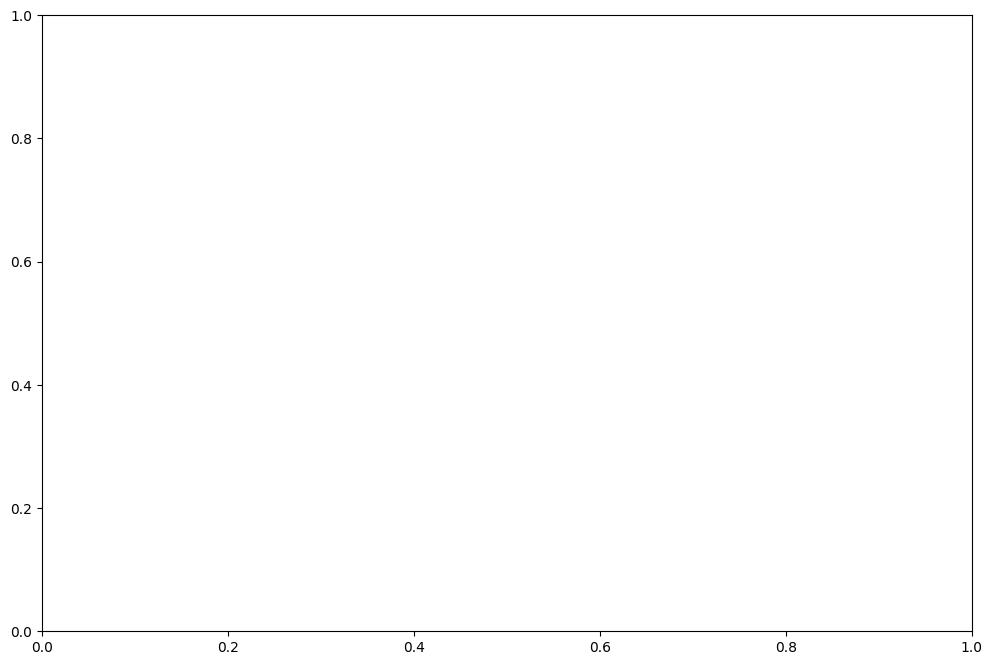

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline  

fig, ax = plt.subplots(1, 1, figsize=(12, 8))
cols = [col for col in test.columns if col not in ['id', 'molecule_name', 'atom_index_0', 'atom_index_1']]
fig = sns.heatmap(test[cols].corr())
test[cols].corr()

In [6]:
# test_with_preds = test_with_preds.sort_values('id')
test['final_preds'] =(
    test['n1']*0.65 +
    test['n2']*0.07 +
    test['lgb_a']*0.14 +
    test['lgb_m']*0.03 +
    test['nnet']*0.04 +
    test['lb']*0.07
)
test.head(20)

KeyError: 'n1'

In [7]:
# seeing only nnet
submission = pd.DataFrame()
submission['id'] = test.id
submission['scalar_coupling_constant'] = test['final_preds']
submission.to_csv('ensemble_sub.csv', index=False)

KeyError: 'final_preds'

In [8]:
submission.head(20)

,id
0,2324604
1,2324605
2,2324606
3,2324607
4,2324608
5,2324609
6,2324610
7,2324611
8,2324612
9,2324613
